In [22]:
from pathlib import Path
import torch

In [23]:
def load_multiple_checkpoint_histories(ckpt_paths, map_location="cpu", verbose=True):
    """
    Load histories from multiple checkpoint files.

    Args:
        ckpt_paths (list): A list of checkpoint paths.
        map_location (str): Device mapping for torch.load, default is 'cpu'.
        verbose (bool): Whether to print basic checkpoint info.

    Returns:
        histories (dict): A dictionary:
            {
                "checkpoint_name": history_list,
                ...
            }
    """
    histories = {}

    for ckpt_path in ckpt_paths:
        ckpt_path = Path(ckpt_path)

        if not ckpt_path.exists():
            print(f"warning: checkpoint not found, skipped: {ckpt_path}")
            continue

        ckpt = torch.load(ckpt_path, map_location=map_location)
        history = ckpt.get("history", [])

        histories[ckpt_path.stem] = history

        if verbose:
            print(f"loaded checkpoint: {ckpt_path}")
            print("  epoch =", ckpt.get("epoch", None))
            print("  best_val_top1_iou =", ckpt.get("best_val_top1_iou", None))
            print("  history length =", len(history))

    return histories

In [48]:
ckpt_paths = [
    "./models/01_candidate_last.pt",
    "./models/02_supportsurface_last.pt",
    "./models/03_ss_hard_last.pt"
]

histories = load_multiple_checkpoint_histories(ckpt_paths)

print(histories.keys())

loaded checkpoint: models\01_candidate_last.pt
  epoch = 10
  best_val_top1_iou = 0.04899203899737087
  history length = 10
loaded checkpoint: models\02_supportsurface_last.pt
  epoch = 5
  best_val_top1_iou = 0.07393623083349198
  history length = 5
loaded checkpoint: models\03_ss_hard_last.pt
  epoch = 7
  best_val_top1_iou = 0.06573342746724525
  history length = 7
dict_keys(['01_candidate_last', '02_supportsurface_last', '03_ss_hard_last'])


In [49]:
import pandas as pd
import numpy as np

def histories_to_dataframe(histories, max_epochs=5):
    rows = []

    for model_name, history in histories.items():
        for item in history[:max_epochs]:
            epoch = item["epoch"]
            train = item["train"]
            val = item["val"]

            # baseline uses mean_iou, others use top1_iou
            train_top1 = train.get("top1_iou", train.get("mean_iou", np.nan))
            val_top1 = val.get("top1_iou", val.get("mean_iou", np.nan))

            # baseline does not have top5_iou
            train_top5 = train.get("top5_iou", np.nan)
            val_top5 = val.get("top5_iou", np.nan)

            rows.append({
                "model": model_name,
                "epoch": epoch,

                "train_loss_total": train.get("loss_total", np.nan),
                "train_top1_iou": train_top1,
                "train_top5_iou": train_top5,

                "val_loss_total": val.get("loss_total", np.nan),
                "val_top1_iou": val_top1,
                "val_top5_iou": val_top5,
            })

    df = pd.DataFrame(rows)
    df = df.sort_values(["model", "epoch"]).reset_index(drop=True)
    return df

## 1. Dataframe summary

In [57]:
name_map = {
    "01_candidate_last": "Candidate",
    "02_supportsurface_last": "SupportSurface",
    "03_ss_hard_last": "HardConstraint",
}
df_compare = histories_to_dataframe(histories, max_epochs=5)
df_compare["model_display"] = df_compare["model"].map(name_map).fillna(df_compare["model"])
df_compare

,model,epoch,train_loss_total,train_top1_iou,train_top5_iou,val_loss_total,val_top1_iou,val_top5_iou,model_display
0,01_candidate_last,1,7.264493,0.025029,0.062807,6.950308,0.026302,0.063308,Candidate
1,01_candidate_last,2,6.819910,0.034996,0.082036,6.854953,0.029424,0.068547,Candidate
2,01_candidate_last,3,6.696489,0.039294,0.089560,6.804021,0.030019,0.068721,Candidate
3,01_candidate_last,4,6.586610,0.044767,0.096157,6.752699,0.032750,0.078246,Candidate
4,01_candidate_last,5,6.468484,0.050863,0.104722,6.735746,0.036395,0.079810,Candidate
5,02_supportsurface_last,1,6.604041,0.053644,0.098901,6.308726,0.056191,0.100460,SupportSurface
6,02_supportsurface_last,2,6.032025,0.069843,0.121148,6.146525,0.063051,0.110614,SupportSurface
7,02_supportsurface_last,3,5.913373,0.074256,0.125143,6.099056,0.070005,0.116754,SupportSurface
8,02_supportsurface_last,4,5.815618,0.076601,0.128097,6.022427,0.073309,0.120075,SupportSurface
9,02_supportsurface_last,5,5.748343,0.083958,0.132213,5.965388,0.073936,0.118644,SupportSurface


## 2. Validation Loss

In [58]:
import matplotlib.pyplot as plt

def plot_val_loss(df, model_col="model_display"):
    plt.figure(figsize=(7, 5))

    for model_name in df[model_col].unique():
        sub_df = df[df[model_col] == model_name].sort_values("epoch")

        if sub_df["val_loss_total"].isna().all():
            continue

        plt.plot(
            sub_df["epoch"],
            sub_df["val_loss_total"],
            marker="o",
            label=model_name
        )

    plt.xlabel("Epoch")
    plt.ylabel("Validation Loss Total")
    plt.title("Validation Loss Total, First 5 Epochs")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

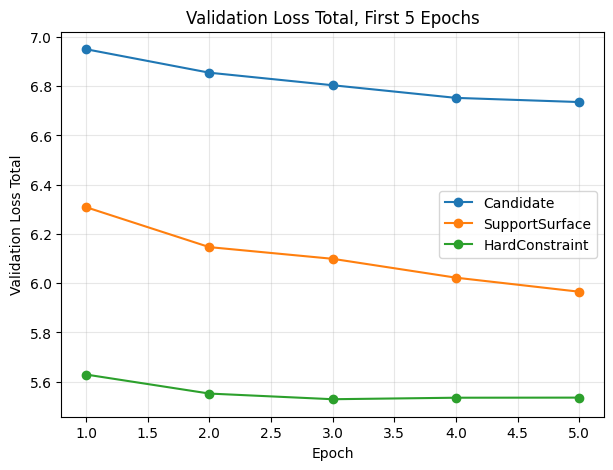

In [59]:
plot_val_loss(df_compare)

## 3. Validation Top1 IoU

In [60]:
def plot_val_top1(df, model_col="model_display"):
    plt.figure(figsize=(7, 5))

    for model_name in df[model_col].unique():
        sub_df = df[df[model_col] == model_name].sort_values("epoch")

        if sub_df["val_top1_iou"].isna().all():
            continue

        plt.plot(
            sub_df["epoch"],
            sub_df["val_top1_iou"],
            marker="o",
            label=model_name
        )

    plt.xlabel("Epoch")
    plt.ylabel("Validation Top1 IoU")
    plt.title("Validation Top1 IoU, First 5 Epochs")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

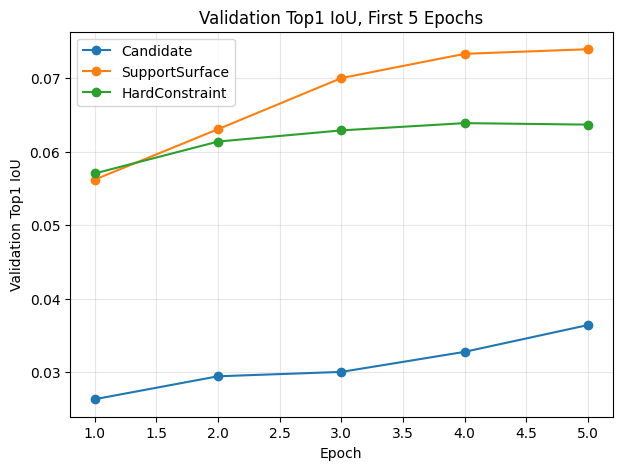

In [61]:
plot_val_top1(df_compare)

## 4. Validation Top5 IoU

In [62]:
def plot_val_top5(df, model_col="model_display"):
    plt.figure(figsize=(7, 5))

    for model_name in df[model_col].unique():
        sub_df = df[df[model_col] == model_name].sort_values("epoch")

        if sub_df["val_top5_iou"].isna().all():
            continue

        plt.plot(
            sub_df["epoch"],
            sub_df["val_top5_iou"],
            marker="o",
            label=model_name
        )

    plt.xlabel("Epoch")
    plt.ylabel("Validation Top5 IoU")
    plt.title("Validation Top5 IoU, First 5 Epochs")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

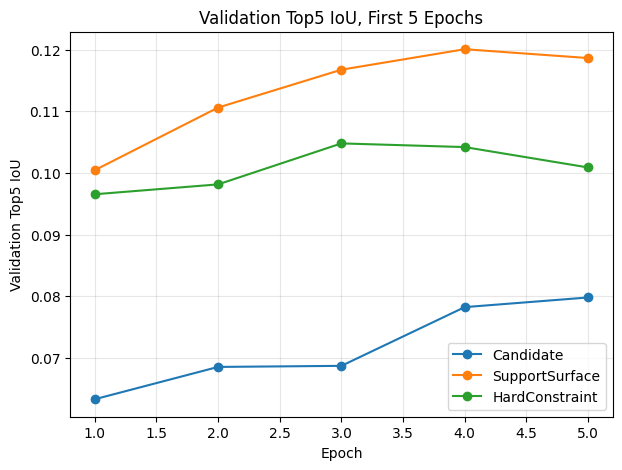

In [63]:
plot_val_top5(df_compare)

## 5. `03_ss_hard_last.pt` training and validation metrics

In [70]:
import torch
import matplotlib.pyplot as plt
from pathlib import Path

def plot_loss_and_iou_curves(
    ckpt_path,
    n_epochs=6,
    title_prefix=None,
    map_location="cpu",
):
    ckpt_path = Path(ckpt_path)
    ckpt = torch.load(ckpt_path, map_location=map_location)

    history = ckpt["history"][:n_epochs]
    if len(history) == 0:
        raise ValueError("No history found in checkpoint.")

    epochs = [item["epoch"] for item in history]

    train_loss = [item["train"]["loss_total"] for item in history]
    val_loss = [item["val"]["loss_total"] for item in history]

    train_top1 = [item["train"]["top1_iou"] for item in history]
    val_top1 = [item["val"]["top1_iou"] for item in history]

    train_top5 = [item["train"]["top5_iou"] for item in history]
    val_top5 = [item["val"]["top5_iou"] for item in history]

    if title_prefix is None:
        title_prefix = ckpt_path.stem

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, train_loss, marker="o", label="Train Loss")
    plt.plot(epochs, val_loss, marker="o", label="Validation Loss")

    plt.xlabel("Epoch")
    plt.ylabel("Loss Total")
    plt.title(f"{title_prefix} - Loss Curves (First {len(epochs)} Epochs)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, train_top1, marker="o", linestyle="-", label="Train Top1 IoU")
    plt.plot(epochs, val_top1, marker="o", linestyle="-", label="Validation Top1 IoU")
    plt.plot(epochs, train_top5, marker="s", linestyle="--", label="Train Top5 IoU")
    plt.plot(epochs, val_top5, marker="s", linestyle="--", label="Validation Top5 IoU")

    plt.xlabel("Epoch")
    plt.ylabel("IoU")
    plt.title(f"{title_prefix} - IoU Curves (First {len(epochs)} Epochs)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

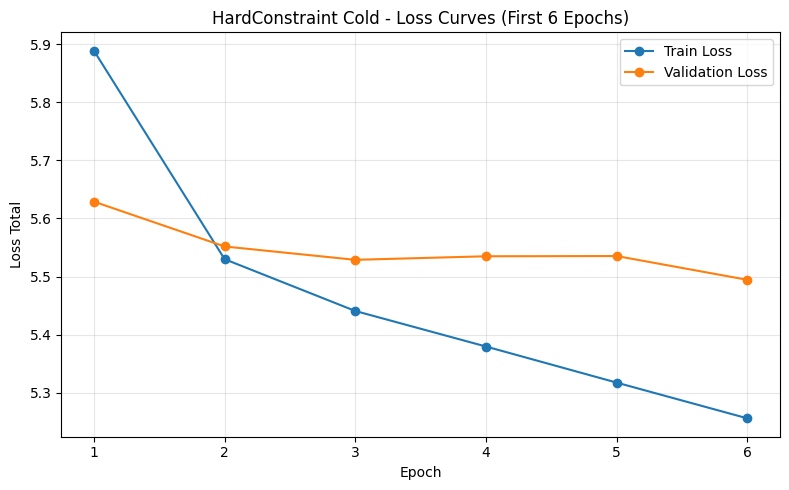

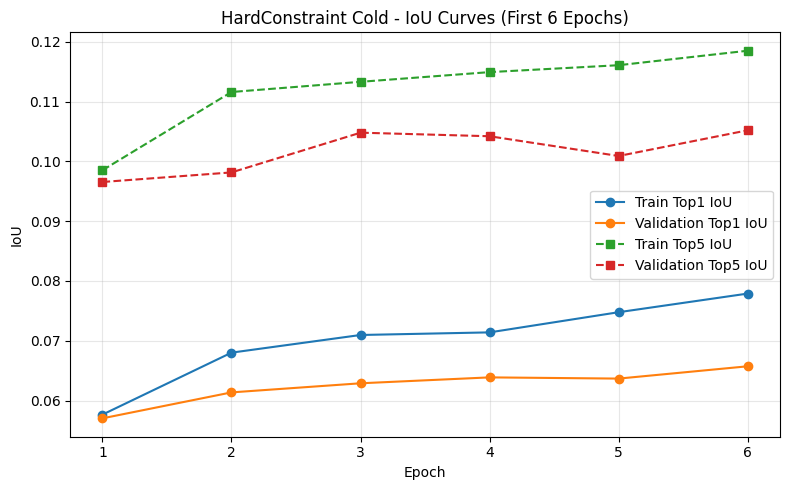

In [71]:
plot_loss_and_iou_curves(
    ckpt_path="./models/03_ss_hard_last.pt",
    n_epochs=6,
    title_prefix="HardConstraint Cold"
)